<a href="https://colab.research.google.com/github/FebrianArkaSamudra/PCVK_2025_FebrianArkaSamudra/blob/main/Week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# **D1 BASIC OBJECT DETECTION**

## Template Matching (6 metode)

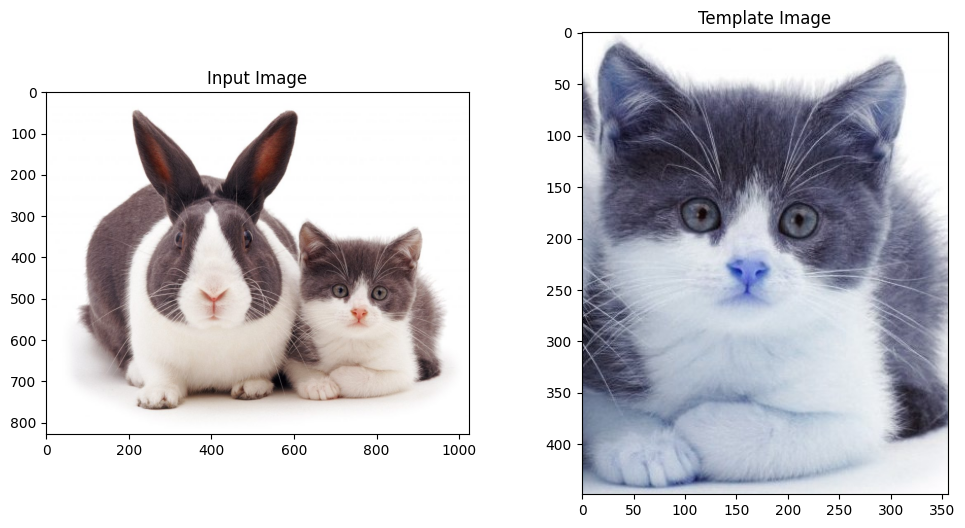

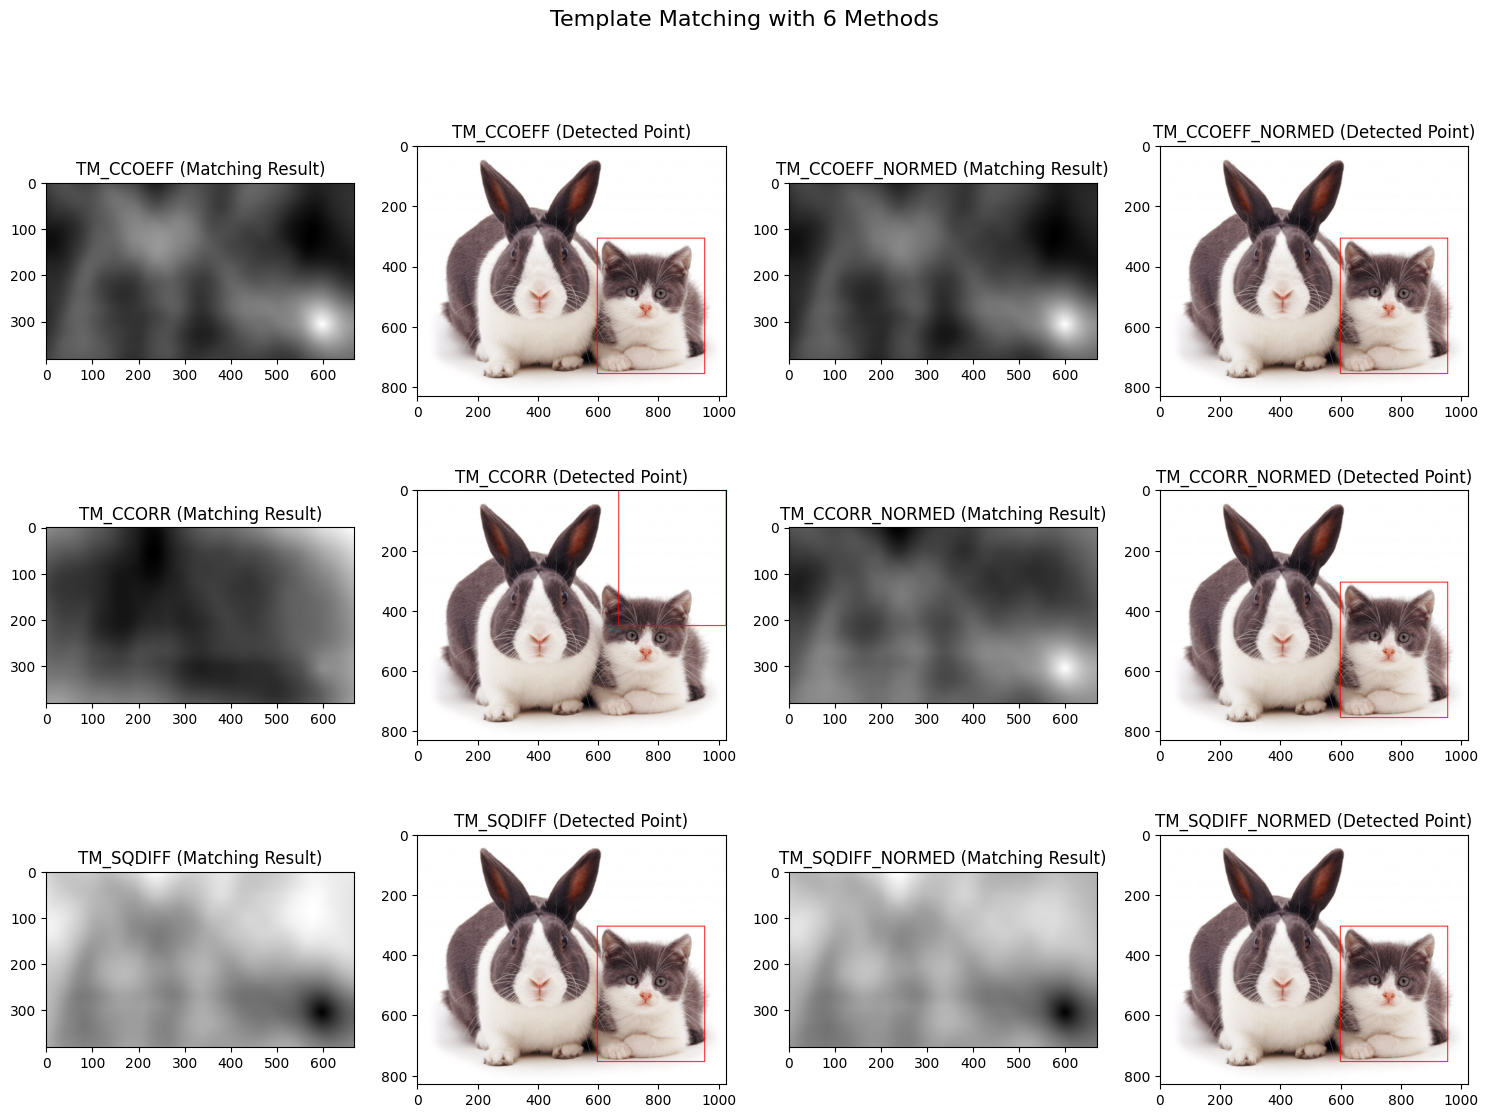

In [24]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/cats_and_bunnies.jpg')
template = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/cat2_templatejpg.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
h, w = template_gray.shape

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.imshow(template, cmap='gray')
plt.title('Template Image')
plt.show()

methods = [
    'TM_CCOEFF', 'TM_CCOEFF_NORMED',
    'TM_CCORR', 'TM_CCORR_NORMED',
    'TM_SQDIFF', 'TM_SQDIFF_NORMED'
]

plt.figure(figsize=(15, 12))
for i, m in enumerate(methods):
    method = eval(f'cv.{m}')

    # Template Matching
    res = cv.matchTemplate(img, template, method)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc  # SQDIFF
    else:
        top_left = max_loc  # CCORR/CCOEFF

    bottom_right = (top_left[0] + w, top_left[1] + h)

    img_display = img.copy()
    cv.rectangle(img_display, top_left, bottom_right, (0, 0, 255), 2)

    plt.subplot(3, 4, 2*i + 1), plt.imshow(res, cmap='gray')
    plt.title(m.replace('cv.', '') + ' (Matching Result)')

    plt.subplot(3, 4, 2*i + 2), plt.imshow(cv.cvtColor(img_display, cv.COLOR_BGR2RGB))
    plt.title(m.replace('cv.', '') + ' (Detected Point)')
plt.suptitle("Template Matching with 6 Methods", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Template Matching tanpa OpenCV (manual)

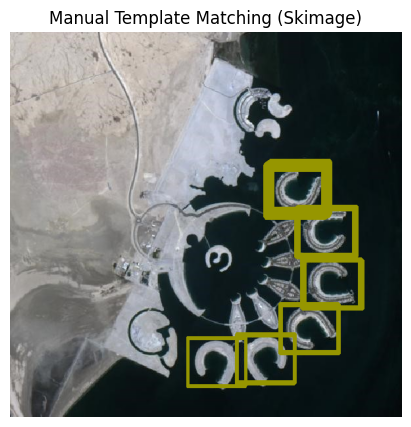

In [26]:
from skimage.feature import match_template
img_color = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/bahrain.jpg')
template_color = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/bahrain-template.jpg')

img = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)
template = cv.cvtColor(template_color, cv.COLOR_BGR2GRAY)

# Perform template matching
result = match_template(img, template)
threshold = 0.45

# Find locations where the match exceeds the threshold
y, x = np.where(result >= threshold)

h, w = template.shape
# Draw rectangles around detected regions
for (x_i, y_i) in zip(x, y):
  cv.rectangle(img_color, (x_i, y_i), (x_i + w, y_i + h),(0,150,150), 2)

# Display result
plt.figure(figsize=(8,5))
plt.imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
plt.title('Manual Template Matching (Skimage)')
plt.axis('off')
plt.show()

## Edge Detection (Sobel, Laplacian, Canny)

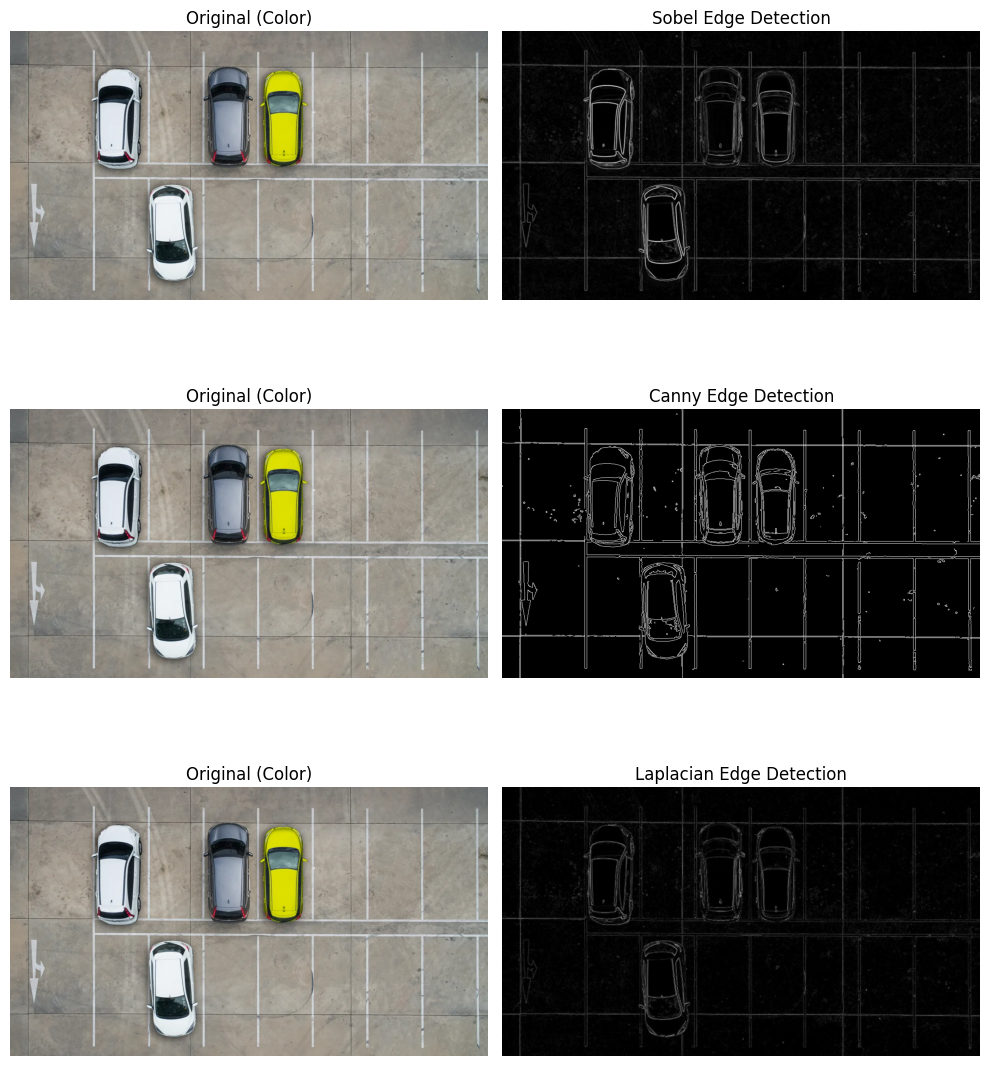

In [5]:
img_color = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/car-park.jpg')
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

# Apply Sobel, Laplacian, and Canny edge detection
sobelx = cv.Sobel(img_gray, cv.CV_64F, 1, 0, ksize=3)
sobely = cv.Sobel(img_gray, cv.CV_64F, 0, 1, ksize=3)
sobel = cv.magnitude(sobelx, sobely)
laplacian = cv.Laplacian(img_gray, cv.CV_64F)
canny = cv.Canny(img_gray, 100, 200)

plt.figure(figsize=(10,12))

# Display Sobel results
plt.subplot(3,2,1)
plt.title('Original (Color)')
plt.imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(3,2,2)
plt.title('Sobel Edge Detection')
plt.imshow(sobel, cmap='gray')
plt.axis('off')

# Display Canny results
plt.subplot(3,2,3)
plt.title('Original (Color)')
plt.imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(3,2,4)
plt.title('Canny Edge Detection')
plt.imshow(canny, cmap='gray')
plt.axis('off')

# Display Laplacian results
plt.subplot(3,2,5)
plt.title('Original (Color)')
plt.imshow(cv.cvtColor(img_color, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(3,2,6)
plt.title('Laplacian Edge Detection')
plt.imshow(np.abs(laplacian), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

## Corner Detection (Harris & Shi-Tomasi)

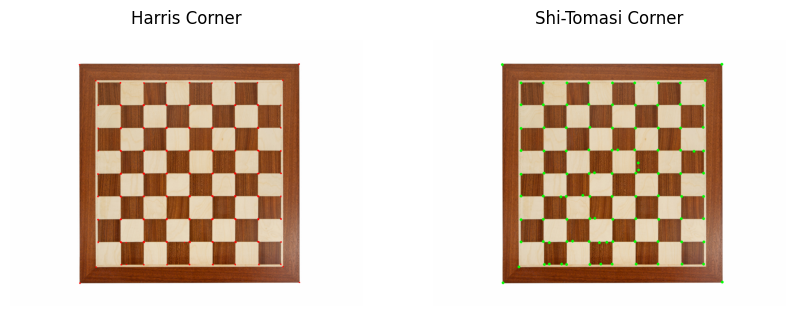

In [6]:
img_color = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/chess-board.jpg')
gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

# Harris Corner Detection
dst = cv.cornerHarris(np.float32(gray), 2, 3, 0.04)
dst = cv.dilate(dst, None)

img_harris = img_color.copy()
# Mark detected corners in red
img_harris[dst > 0.01 * dst.max()] = [0, 0, 255]

# Shi-Tomasi Corner Detection
corners = cv.goodFeaturesToTrack(gray, 100, 0.01, 10)
img_shi = img_color.copy()
# Draw circles around detected corners
for c in corners:
    x, y = c.ravel()
    cv.circle(img_shi, (int(x), int(y)), 4, (0, 255, 0), -1)

# Display results
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Harris Corner')
plt.imshow(cv.cvtColor(img_harris, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Shi-Tomasi Corner')
plt.imshow(cv.cvtColor(img_shi, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

## Hough Transform (Deteksi Grid Sudoku)

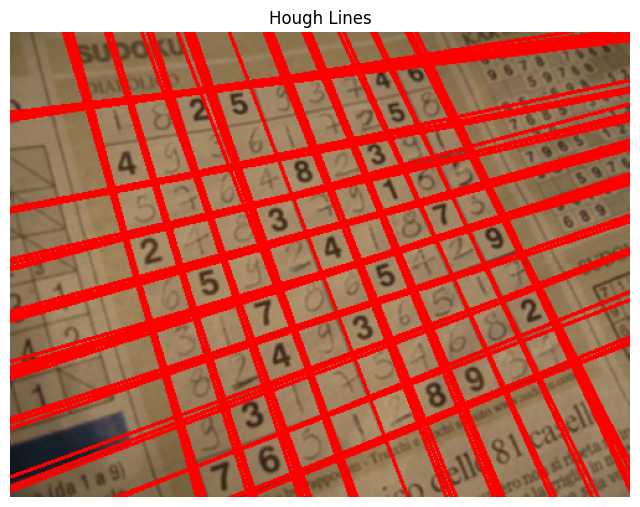

In [7]:
img_path = '/content/drive/MyDrive/PCVK/Images/Object Detection/sudoku.jpg'
img = cv.imread(img_path)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
blur = cv.GaussianBlur(gray, (5,5), 0)
edges = cv.Canny(blur, 50, 150)

img_lines_std = img.copy()
# Apply Standard Hough Line Transform
lines_std = cv.HoughLines(edges, 1, np.pi/180, 120)

if lines_std is not None:
    for line in lines_std:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv.line(img_lines_std, (x1,y1), (x2,y2), (0,0,255), 2)

plt.figure(figsize=(8, 8))
plt.title("Hough Lines")
plt.imshow(cv.cvtColor(img_lines_std, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## Countour Detection

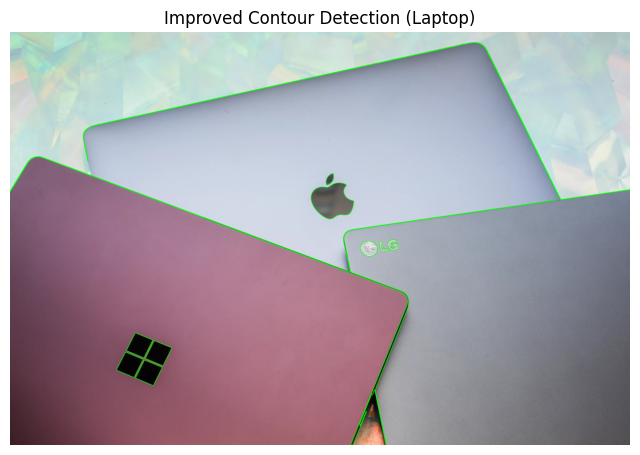

In [8]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/laptop.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Apply Gaussian blur and Canny edge detection
blur = cv.GaussianBlur(gray, (5,5), 0)
edges = cv.Canny(blur, 50, 150)

# Dilate and erode edges to improve contours
kernel = np.ones((3,3), np.uint8)
edges = cv.dilate(edges, kernel, iterations=2)
edges = cv.erode(edges, kernel, iterations=1)

# Find contours
contours, hierarchy = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

out = img.copy()
# Draw contours with area greater than 500
for c in contours:
    area = cv.contourArea(c)
    if area > 500:
        cv.drawContours(out, [c], -1, (0,255,0), 2)

plt.figure(figsize=(8,6))
plt.title('Improved Contour Detection (Laptop)')
plt.imshow(cv.cvtColor(out, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# D2. FEATURE MATCHING AND FACE DETECTION PRACTICUM

## Face Detection Haar Cascade

Found 9 images. Starting face detection...



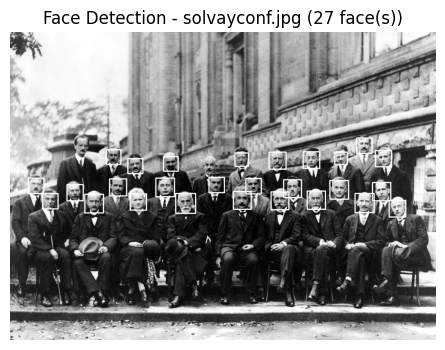

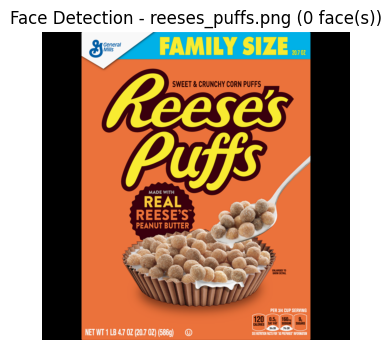

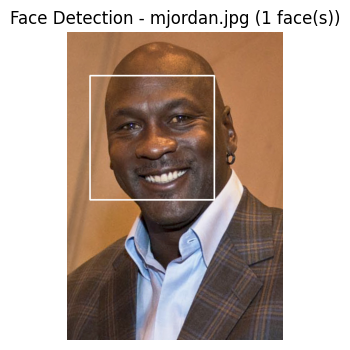

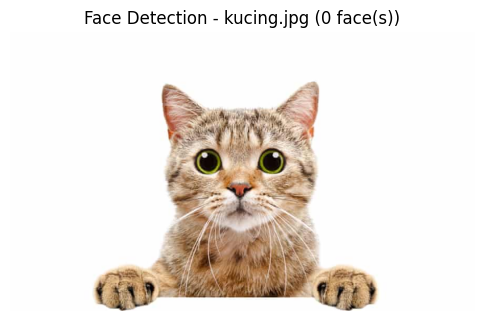

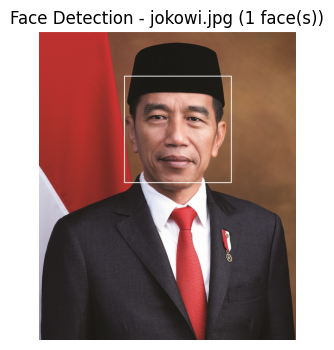

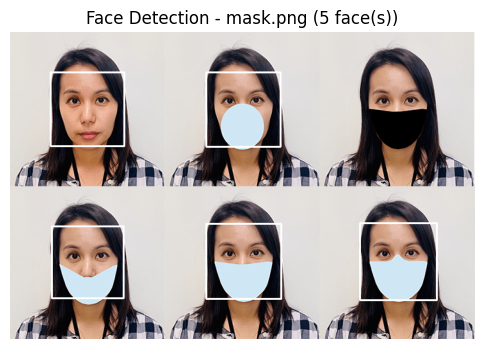

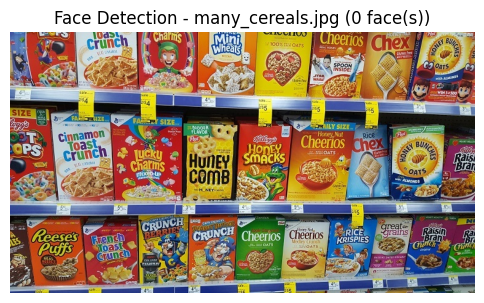

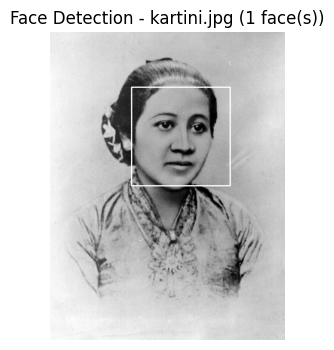

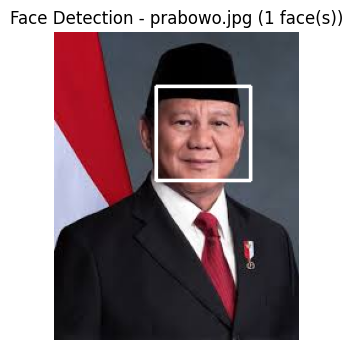

In [9]:
import cv2 as cv
import matplotlib.pyplot as plt
import os

cascade_path = '/content/drive/MyDrive/PCVK/Images/haarcascades/haarcascade_frontalface_alt.xml'
img_folder = '/content/drive/MyDrive/PCVK/Images/facedet'

# Load Haar Cascade classifier
cascade = cv.CascadeClassifier(cascade_path)

# Check if cascade file loaded successfully
if cascade.empty():
    raise IOError("Failed to load cascade file. Check the XML path!")

# Get all image files in the folder
image_files = [f for f in os.listdir(img_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if not image_files:
    print("No image files found in folder:", img_folder)
else:
    print(f"Found {len(image_files)} images. Starting face detection...\n")

# Loop through each image
for filename in image_files:
    img_path = os.path.join(img_folder, filename)
    img = cv.imread(img_path)

    if img is None:
        print(f"Failed to read {filename}, skipping.")
        continue

    # Convert image to grayscale
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Detect faces
    faces = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    # Draw white rectangles around detected faces
    for (x, y, w, h) in faces:
        cv.rectangle(img, (x, y), (x+w, y+h), (255, 255, 255), 2)

    plt.figure(figsize=(6,4))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(f'Face Detection - {filename} ({len(faces)} face(s))')
    plt.axis('off')
    plt.show()


Total detections: 2
Main cat face detected.


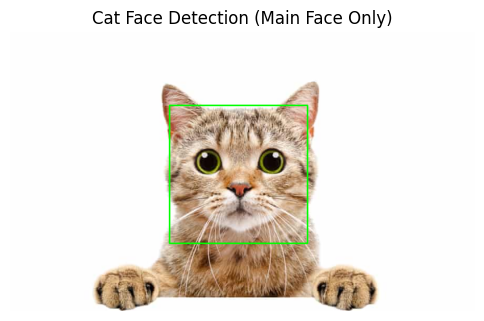

In [10]:
import cv2 as cv
import matplotlib.pyplot as plt

cascade_path = '/content/drive/MyDrive/PCVK/Images/haarcascades/haarcascade_frontalcatface_extended.xml'
img_path = '/content/drive/MyDrive/PCVK/Images/facedet/kucing.jpg'

# Load classifier
cat_cascade = cv.CascadeClassifier(cascade_path)

img = cv.imread(img_path)
if img is None:
    raise ValueError("Image not found! Check your img_path.")

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Detect cat faces
cats = cat_cascade.detectMultiScale(
    gray,
    scaleFactor=1.02,
    minNeighbors=3,
    minSize=(50, 50)
)

print(f"Total detections: {len(cats)}")

# If detections are found
if len(cats) > 0:
    # Sort by area (w*h), get the largest face
    cats = sorted(cats, key=lambda box: box[2] * box[3], reverse=True)
    x, y, w, h = cats[0]

    # Draw rectangle around the main face
    cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    print("Main cat face detected.")
else:
    print("No cat face detected.")

plt.figure(figsize=(6,5))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Cat Face Detection (Main Face Only)')
plt.axis('off')
plt.show()


Number of eyes detected: 2


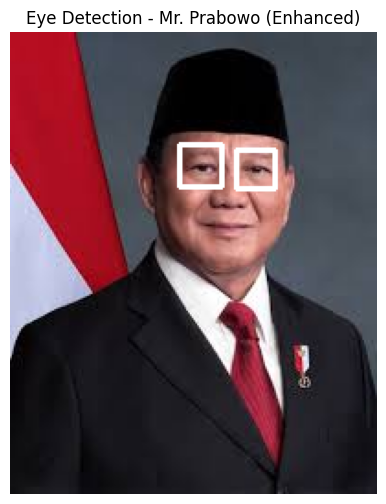

In [11]:
import cv2 as cv
import matplotlib.pyplot as plt

eye_cascade_path = '/content/drive/MyDrive/PCVK/Images/haarcascades/haarcascade_eye.xml'
img_path = '/content/drive/MyDrive/PCVK/Images/facedet/prabowo.jpg'

# Load model
eye_cascade = cv.CascadeClassifier(eye_cascade_path)
if eye_cascade.empty():
    raise IOError("Failed to load cascade XML. Check your model path!")

# Read image
img = cv.imread(img_path)
if img is None:
    raise ValueError("Image not found! Check your image path.")

# Preprocessing for improved detection
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray = cv.equalizeHist(gray)           # Improve lighting
gray = cv.GaussianBlur(gray, (3, 3), 0)  # Reduce subtle noise

# Detect eyes directly
eyes = eye_cascade.detectMultiScale(
    gray,
    scaleFactor=1.03,
    minNeighbors=2,
    minSize=(20, 20)
)

print(f"Number of eyes detected: {len(eyes)}")

# Draw white rectangles around each eye
for (x, y, w, h) in eyes:
    cv.rectangle(img, (x, y), (x+w, y+h), (255, 255, 255), 2)

# Display result
plt.figure(figsize=(7,6))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Eye Detection - Mr. Prabowo (Enhanced)')
plt.axis('off')
plt.show()

## Smile Detection


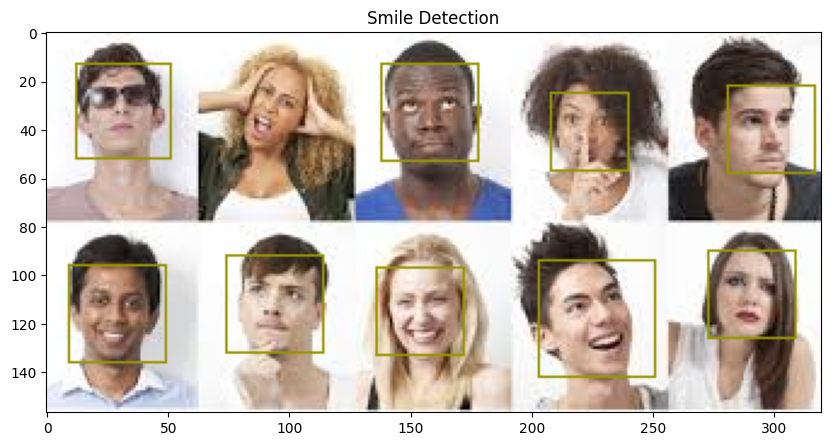

In [12]:
# Load cascades
face_cascade = cv.CascadeClassifier('/content/drive/MyDrive/PCVK/Images/haarcascades/haarcascade_frontalface_alt.xml')
smile_cascade = cv.CascadeClassifier('/content/drive/MyDrive/PCVK/Images/haarcascades/haarcascade_smile.xml')

# Image path
people_path = '/content/drive/MyDrive/PCVK/Images/people.jpeg'
img = cv.imread(people_path)

# Convert to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.1, 4)

for (x, y, w, h) in faces:
    cv.rectangle(img, (x, y), (x + w, y + h), (0, 150, 150), 1)
    roi_gray = gray[y:y + h, x:x + w]
    roi_color = img[y:y + h, x:x + w]

    smiles = smile_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    for (sx, sy, sw, sh) in smiles:
        cv.rectangle(roi_color, (sx, sy), (sx + sw, sy + sh), (0, 0, 255), 1)

# Result
plt.figure(figsize=(10, 6))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Smile Detection")
plt.show()

## Face Tracking

In [13]:
# import dependencies
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np
import PIL
import io
import html
import time

In [14]:
# function to convert the JavaScript object into an OpenCV image
def js_to_image(js_reply):
  """
  Params:
          js_reply: JavaScript object containing image from webcam
  Returns:
          img: OpenCV BGR image
  """
  # decode base64 image
  image_bytes = b64decode(js_reply.split(',')[1])
  # convert bytes to numpy array
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  # decode numpy array into OpenCV BGR image
  img = cv2.imdecode(jpg_as_np, flags=1)

  return img

# function to convert OpenCV Rectangle bounding box image into base64 byte string to be overlayed on video stream
def bbox_to_bytes(bbox_array):
  """
  Params:
          bbox_array: Numpy array (pixels) containing rectangle to overlay on video stream.
  Returns:
        bytes: Base64 image byte string
  """
  # convert array into PIL image
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
  iobuf = io.BytesIO()
  # format bbox into png for return
  bbox_PIL.save(iobuf, format='png')
  # format return string
  bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))

  return bbox_bytes

## Haar cascade

In [15]:
# initialize the Haar Cascade face detection model
face_cascade = cv2.CascadeClassifier(cv2.samples.findFile(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'))


## Webcam Images

In [16]:
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)

  # get photo data
  data = eval_js('takePhoto({})'.format(quality))
  # get OpenCV format image
  img = js_to_image(data)
  # grayscale img
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  print(gray.shape)
  # get face bounding box coordinates using Haar Cascade
  faces = face_cascade.detectMultiScale(gray)
  # draw face bounding box on image
  for (x,y,w,h) in faces:
      img = cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)
  # save image
  cv2.imwrite(filename, img)

  return filename

<IPython.core.display.Javascript object>

(480, 640)
Saved to photo.jpg


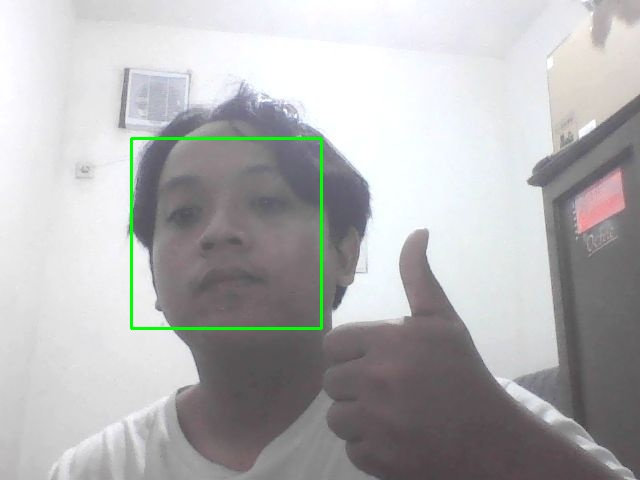

In [17]:
try:
  filename = take_photo('photo.jpg')
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

## Webcam Videos

In [18]:
# JavaScript to properly create our live video stream using our webcam as input
def video_stream():
  js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var imgElement;
    var labelElement;

    var pendingResolve = null;
    var shutdown = false;

    function removeDom() {
       stream.getVideoTracks()[0].stop();
       video.remove();
       div.remove();
       video = null;
       div = null;
       stream = null;
       imgElement = null;
       captureCanvas = null;
       labelElement = null;
    }

    function onAnimationFrame() {
      if (!shutdown) {
        window.requestAnimationFrame(onAnimationFrame);
      }
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) {
        return stream;
      }

      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '3px';
      div.style.width = '100%';
      div.style.maxWidth = '600px';
      document.body.appendChild(div);

      const modelOut = document.createElement('div');
      modelOut.innerHTML = "Status:";
      labelElement = document.createElement('span');
      labelElement.innerText = 'No data';
      labelElement.style.fontWeight = 'bold';
      modelOut.appendChild(labelOut);
      div.appendChild(modelOut);

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = div.clientWidth - 6;
      video.setAttribute('playsinline', '');
      video.onclick = () => { shutdown = true; };
      stream = await navigator.mediaDevices.getUserMedia(
          {video: { facingMode: "environment"}});
      div.appendChild(video);

      imgElement = document.createElement('img');
      imgElement.style.position = 'absolute';
      imgElement.style.zIndex = 1;
      imgElement.onclick = () => { shutdown = true; };
      div.appendChild(imgElement);

      const instruction = document.createElement('div');
      instruction.innerHTML =
          '' +
          'When finished, click here or on the video to stop this demo';
      div.appendChild(instruction);
      instruction.onclick = () => { shutdown = true; };

      video.srcObject = stream;
      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640; //video.videoWidth;
      captureCanvas.height = 480; //video.videoHeight;
      window.requestAnimationFrame(onAnimationFrame);

      return stream;
    }
    async function stream_frame(label, imgData) {
      if (shutdown) {
        removeDom();
        shutdown = false;
        return '';
      }

      var preCreate = Date.now();
      stream = await createDom();

      var preShow = Date.now();
      if (label != "") {
        labelElement.innerHTML = label;
      }

      if (imgData != "") {
        var videoRect = video.getClientRects()[0];
        imgElement.style.top = videoRect.top + "px";
        imgElement.style.left = videoRect.left + "px";
        imgElement.style.width = videoRect.width + "px";
        imgElement.style.height = videoRect.height + "px";
        imgElement.src = imgData;
      }

      var preCapture = Date.now();
      var result = await new Promise(function(resolve, reject) {
        pendingResolve = resolve;
      });
      shutdown = false;

      return {'create': preShow - preCreate,
              'show': preCapture - preShow,
              'capture': Date.now() - preCapture,
              'img': result};
    }
    ''')

  display(js)

def video_frame(label, bbox):
  data = eval_js('stream_frame("{}", "{}")'.format(label, bbox))
  return data

In [19]:
# start streaming video from webcam
video_stream()
# label for video
label_html = 'Capturing...'
# initialze bounding box to empty
bbox = ''
count = 0
while True:
    js_reply = video_frame(label_html, bbox)
    if not js_reply:
        break

    # convert JS response to OpenCV Image
    img = js_to_image(js_reply["img"])

    # create transparent overlay for bounding box
    bbox_array = np.zeros([480,640,4], dtype=np.uint8)

    # grayscale image for face detection
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # get face region coordinates
    faces = face_cascade.detectMultiScale(gray)
    # get face bounding box for overlay
    for (x,y,w,h) in faces:
      bbox_array = cv2.rectangle(bbox_array,(x,y),(x+w,y+h),(255,0,0),2)

    bbox_array[:,:,3] = (bbox_array.max(axis = 2) > 0 ).astype(int) * 255
    # convert overlay of bbox into bytes
    bbox_bytes = bbox_to_bytes(bbox_array)
    # update bbox so next frame gets new overlay
    bbox = bbox_bytes

<IPython.core.display.Javascript object>

/tmp/ipython-input-480462610.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
/tmp/ipython-input-480462610.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')


## Blurring Effect

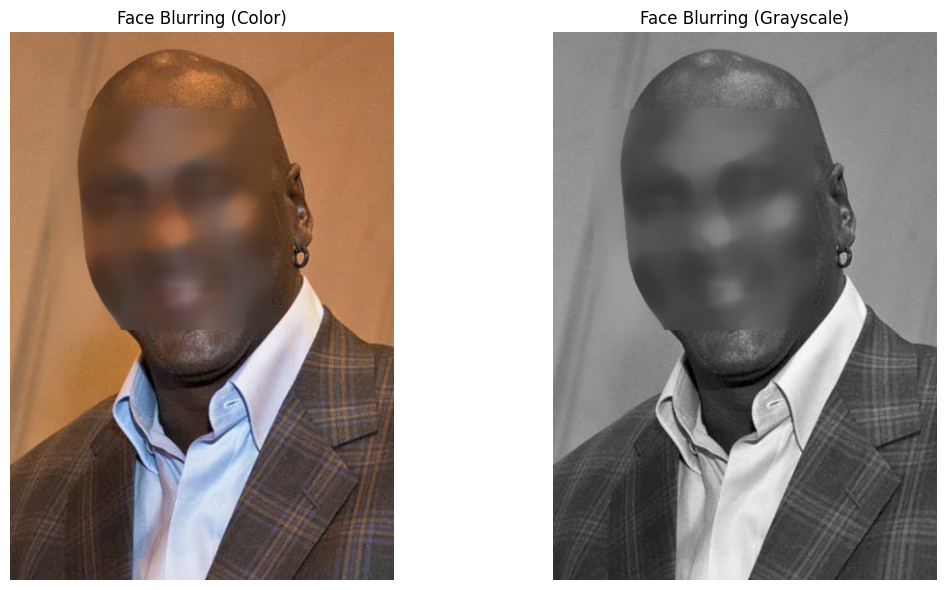

In [20]:
cascade = cv.CascadeClassifier('/content/drive/MyDrive/PCVK/Images/haarcascades/haarcascade_frontalface_alt.xml')

img = cv.imread('/content/drive/MyDrive/PCVK/Images/facedet/mjordan.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

faces = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

img_color_blur = img.copy()
img_gray_blur = gray.copy()

for (x, y, w, h) in faces:
    roi_color = img_color_blur[y:y+h, x:x+w]
    roi_gray = img_gray_blur[y:y+h, x:x+w]
    # blur
    blur_color = cv.medianBlur(roi_color, 35)
    blur_gray = cv.medianBlur(roi_gray, 35)
    img_color_blur[y:y+h, x:x+w] = blur_color
    img_gray_blur[y:y+h, x:x+w] = blur_gray

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(img_color_blur, cv.COLOR_BGR2RGB))
plt.title('Face Blurring (Color)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_gray_blur, cmap='gray')
plt.title('Face Blurring (Grayscale)')
plt.axis('off')

plt.tight_layout()
plt.show()


## KTM

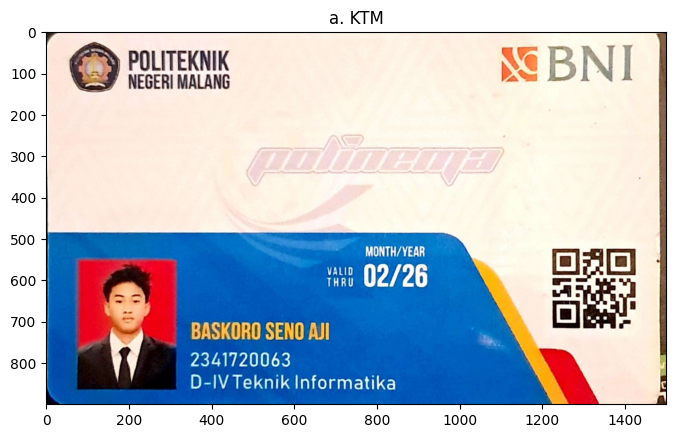

In [21]:
img_ktm = cv.imread('/content/drive/MyDrive/PCVK/Images/KTM_Group1.jpg')

plt.figure(figsize=(8,6))
plt.imshow(cv.cvtColor(img_ktm, cv.COLOR_BGR2RGB))
plt.title('a. KTM')
plt.axis('on')
plt.show()


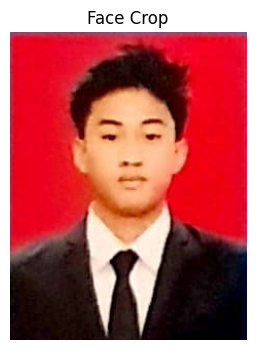

In [22]:
face_crop = img_ktm[550:850, 80:310]

plt.figure(figsize=(4,4))
plt.imshow(cv.cvtColor(face_crop, cv.COLOR_BGR2RGB))
plt.title('Face Crop')
plt.axis('off')
plt.show()


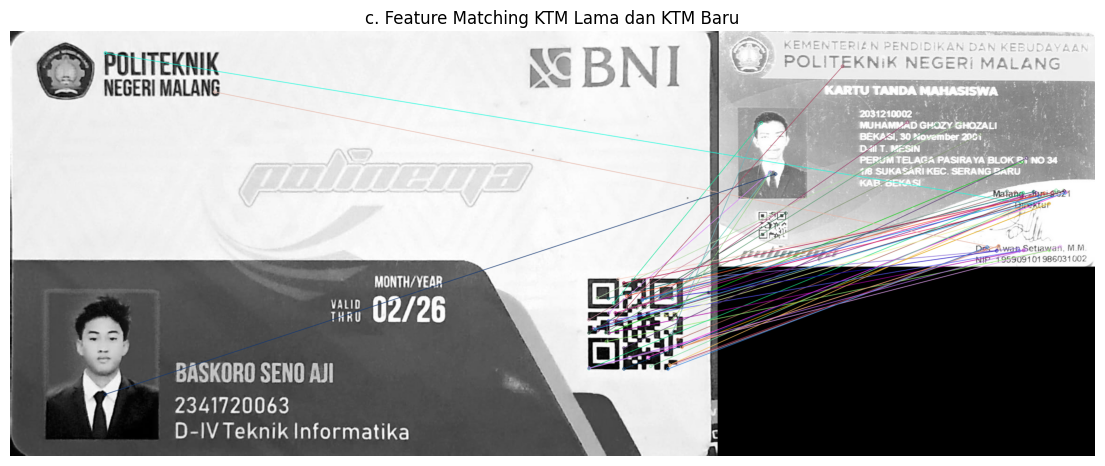

In [23]:
img1 = cv.imread('/content/drive/MyDrive/PCVK/Images/KTM_Group1.jpg', 0)
img2 = cv.imread('/content/drive/MyDrive/PCVK/Images/KTM lama.jpg', 0)

# ORB for Fetaure Detection
orb = cv.ORB_create(1500)
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

result = cv.drawMatches(img1, kp1, img2, kp2, matches[:50], None, flags=2)

plt.figure(figsize=(14,7))
plt.imshow(result, cmap='gray')
plt.title('c. Feature Matching KTM Lama dan KTM Baru')
plt.axis('off')
plt.show()


## Aditional Practicum Assignment